In [1]:
import sys
from pathlib import Path
# Add parent directory to path to import synctools modules
sys.path.insert(0, str(Path().resolve().parent))

import numpy as np
import matplotlib.pyplot as plt
from speckit import noise

from synctools.synchronization import sync_multiple_twosignals

# Configure SpecKit parameters for spectral analysis
p_lpsd = {
    "olap": "default",
    "bmin": 1.0,
    "Lmin": 1,
    "Jdes": 500,
    "Kdes": 100,
    "order": 1,
    "win": np.kaiser,
    "psll": 250,
}

# Set up matplotlib for better plots
plt.style.use('default')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['font.size'] = 10

# Multiple 2-Signal Synchronization Demonstration

This notebook demonstrates the `sync_multiple_twosignals` function for **multiple 2-signal synchronizations** using a common reference signal.

**Key concept:** `sync_multiple_twosignals` takes N input signals (A, B, C, D, ...) and performs TwoSignal synchronization for each pair [A,B], [A,C], [A,D], etc., where A is the first signal used as the reference. This is useful when you have multiple phasemeter signals that all need to be synchronized to a common reference.**

**Both TwoSignals and ThreeSignals represent null measurements** that should cancel to zero when the participating signals are properly synchronized. The `sync_multiple_twosignals` function optimizes for the time offsets that, when applied to the input signals, recover the null measurement for each pair.

For multiple 2-signal sync, we use multiple signals that measure the same quantity (e.g., the same laser beat frequency from different phasemeters). When synchronized, each combination (A - B, A - C, A - D, etc.) should be zero. When unsynchronized, time offsets cause the null measurements to fail, showing large artifacts. The synchronization process recovers the correct offsets to restore the nulls.

## Setup: Generate Synthetic Signals with Known Time Offsets

We'll create four frequency signals (A, B, C, D) that measure the same beat frequency, with intentional time offsets to demonstrate the synchronization capability. Signal A will be used as the reference.

In [2]:
# Signal generation parameters
N = int(1e4)  # Number of samples
noise_level = 1000  # Laser frequency noise level
nu_laser = 299792458 / 1064.5e-9  # Nominal laser frequency (Hz)
fs = 3.3  # Sampling frequency of the phasemeters (Hz)

# Generate random walk noise (red noise) for laser frequency noise
rw_A = noise.red_noise(fs, f_min=1e-3, seed=41)
rw_B = noise.red_noise(fs, f_min=1e-3, seed=42)
rw_C = noise.red_noise(fs, f_min=1e-3, seed=43)
rw_D = noise.red_noise(fs, f_min=1e-3, seed=44)

# Create laser frequencies with different offsets
laser_A = nu_laser - 5e6 + noise_level * rw_A.get_series(N)  # Laser frequency (Hz)
laser_B = nu_laser - 15e6 + noise_level * rw_B.get_series(N)  # Laser frequency (Hz)
laser_C = nu_laser - 10e6 + noise_level * rw_C.get_series(N)  # Laser frequency (Hz)
laser_D = nu_laser - 20e6 + noise_level * rw_D.get_series(N)  # Laser frequency (Hz)

# Create phasemeter signals (PIR values)
# For 2-signal null measurement: all measure the same beat frequency
# When synchronized, A - B, A - C, A - D should all be zero (null measurements)
beat_freq = laser_A - laser_B  # Common beat frequency being measured

signal_A = beat_freq  # Phasemeter A, PIR value (Hz) - REFERENCE
signal_B = beat_freq  # Phasemeter B, same measurement (Hz)
signal_C = beat_freq  # Phasemeter C, same measurement (Hz)
signal_D = beat_freq  # Phasemeter D, same measurement (Hz)

print(f"Signal means: A={np.mean(signal_A)/1e6:.2f} MHz, B={np.mean(signal_B)/1e6:.2f} MHz")
print(f"Signal means: C={np.mean(signal_C)/1e6:.2f} MHz, D={np.mean(signal_D)/1e6:.2f} MHz")
print(f"Signal lengths: {len(signal_A)} samples")
print(f"Sampling rate: {fs} Hz")
print(f"Duration: {len(signal_A)/fs:.1f} seconds")
print(f"\nWhen perfectly synchronized, A-B, A-C, A-D should all be zero (null measurements)")
print(f"Initial differences RMS:")
print(f"  A-B: {np.std(signal_A - signal_B):.2e} Hz")
print(f"  A-C: {np.std(signal_A - signal_C):.2e} Hz")
print(f"  A-D: {np.std(signal_A - signal_D):.2e} Hz")

Signal means: A=10.03 MHz, B=10.03 MHz
Signal means: C=10.03 MHz, D=10.03 MHz
Signal lengths: 10000 samples
Sampling rate: 3.3 Hz
Duration: 3030.3 seconds

When perfectly synchronized, A-B, A-C, A-D should all be zero (null measurements)
Initial differences RMS:
  A-B: 0.00e+00 Hz
  A-C: 0.00e+00 Hz
  A-D: 0.00e+00 Hz


## Plot 1: Input Signals

Visualize all four input frequency signals. Signal A is the reference.

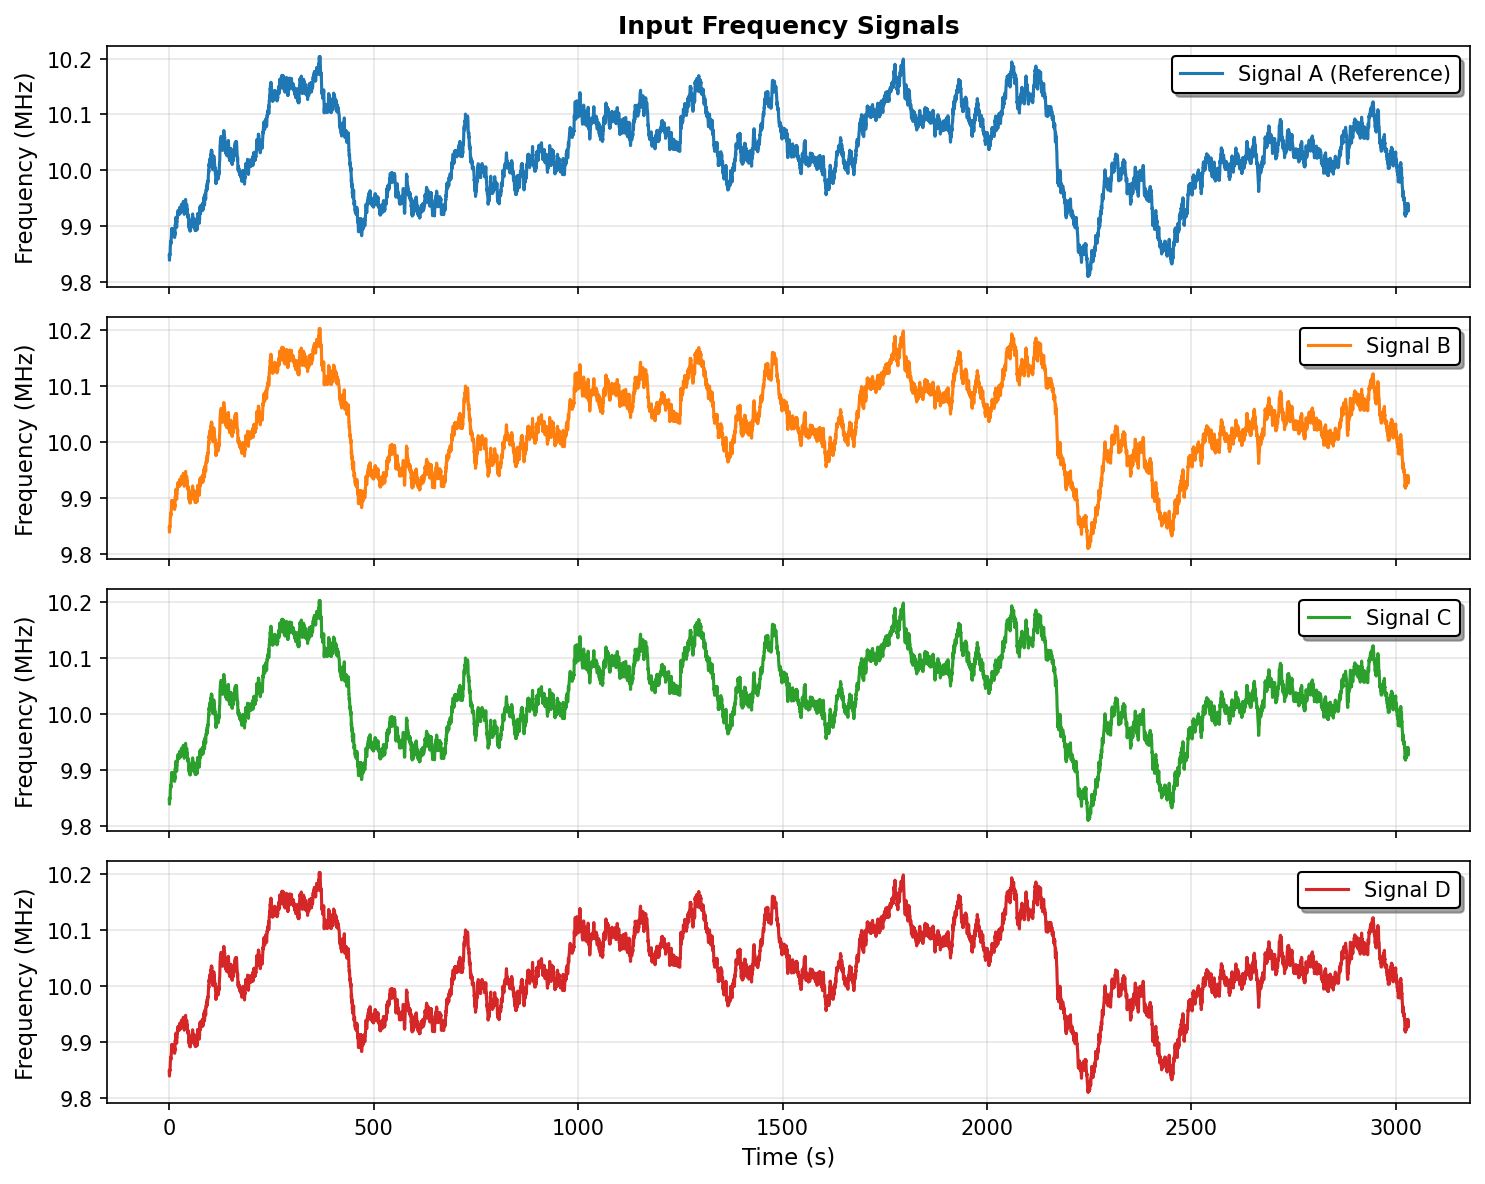

In [3]:
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

time_axis = np.arange(len(signal_A)) / fs
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
labels = ['Signal A (Reference)', 'Signal B', 'Signal C', 'Signal D']

for i, (sig, color, label) in enumerate(zip([signal_A, signal_B, signal_C, signal_D], colors, labels)):
    axes[i].plot(time_axis, sig / 1e6, color=color, linewidth=1.5, label=label)
    axes[i].set_ylabel('Frequency (MHz)', fontsize=11)
    axes[i].legend(loc='upper right', edgecolor='black', fancybox=True, shadow=True, framealpha=1)
    axes[i].grid(True, alpha=0.3)

axes[0].set_title('Input Frequency Signals', fontsize=12, fontweight='bold')
axes[-1].set_xlabel('Time (s)', fontsize=11)

fig.tight_layout()
plt.show()

## Introduce Time Offsets

Now we'll introduce intentional time offsets to simulate unsynchronized phasemeters. Each signal (B, C, D) will have a different offset relative to the reference signal A. This will cause the null measurements to fail, showing large artifacts. Synchronization will recover the nulls by finding the correct offsets.

In [4]:
# Introduce time offsets (in samples) for each signal
shift_B = int(1.2 * fs)  # ~1.2 seconds offset for signal B
shift_C = int(2.5 * fs)  # ~2.5 seconds offset for signal C
shift_D = int(0.8 * fs)  # ~0.8 seconds offset for signal D

# Apply shifts (signal A is the reference, signals B, C, D are shifted)
# We need to find a common length that works for all signals
max_shift = max(shift_B, shift_C, shift_D)

signal_A_shifted = signal_A[:-2*max_shift]
signal_B_shifted = signal_B[shift_B:-shift_B] if shift_B <= len(signal_B) - shift_B else signal_B[shift_B:]
signal_C_shifted = signal_C[shift_C:-shift_C] if shift_C <= len(signal_C) - shift_C else signal_C[shift_C:]
signal_D_shifted = signal_D[shift_D:-shift_D] if shift_D <= len(signal_D) - shift_D else signal_D[shift_D:]

# Find common length
min_len = min(len(signal_A_shifted), len(signal_B_shifted), len(signal_C_shifted), len(signal_D_shifted))
signal_A_shifted = signal_A_shifted[:min_len]
signal_B_shifted = signal_B_shifted[:min_len]
signal_C_shifted = signal_C_shifted[:min_len]
signal_D_shifted = signal_D_shifted[:min_len]

# True offsets in seconds
true_offset_B = shift_B / fs
true_offset_C = shift_C / fs
true_offset_D = shift_D / fs

print(f"Applied time offsets:")
print(f"  Signal B: {true_offset_B:.3f} seconds ({shift_B} samples)")
print(f"  Signal C: {true_offset_C:.3f} seconds ({shift_C} samples)")
print(f"  Signal D: {true_offset_D:.3f} seconds ({shift_D} samples)")
print(f"Final signal length: {len(signal_A_shifted)} samples ({len(signal_A_shifted)/fs:.1f} seconds)")

# Verify all signals have the same length
assert len(signal_A_shifted) == len(signal_B_shifted) == len(signal_C_shifted) == len(signal_D_shifted)

Applied time offsets:
  Signal B: 0.909 seconds (3 samples)
  Signal C: 2.424 seconds (8 samples)
  Signal D: 0.606 seconds (2 samples)
Final signal length: 9984 samples (3025.5 seconds)


## Plot 2: Null Measurements Before Synchronization

The 2-signal combinations are the null measurements A-B, A-C, A-D. When perfectly synchronized, these should all be zero. Before synchronization, the time offsets cause the null measurements to fail, showing large artifacts.

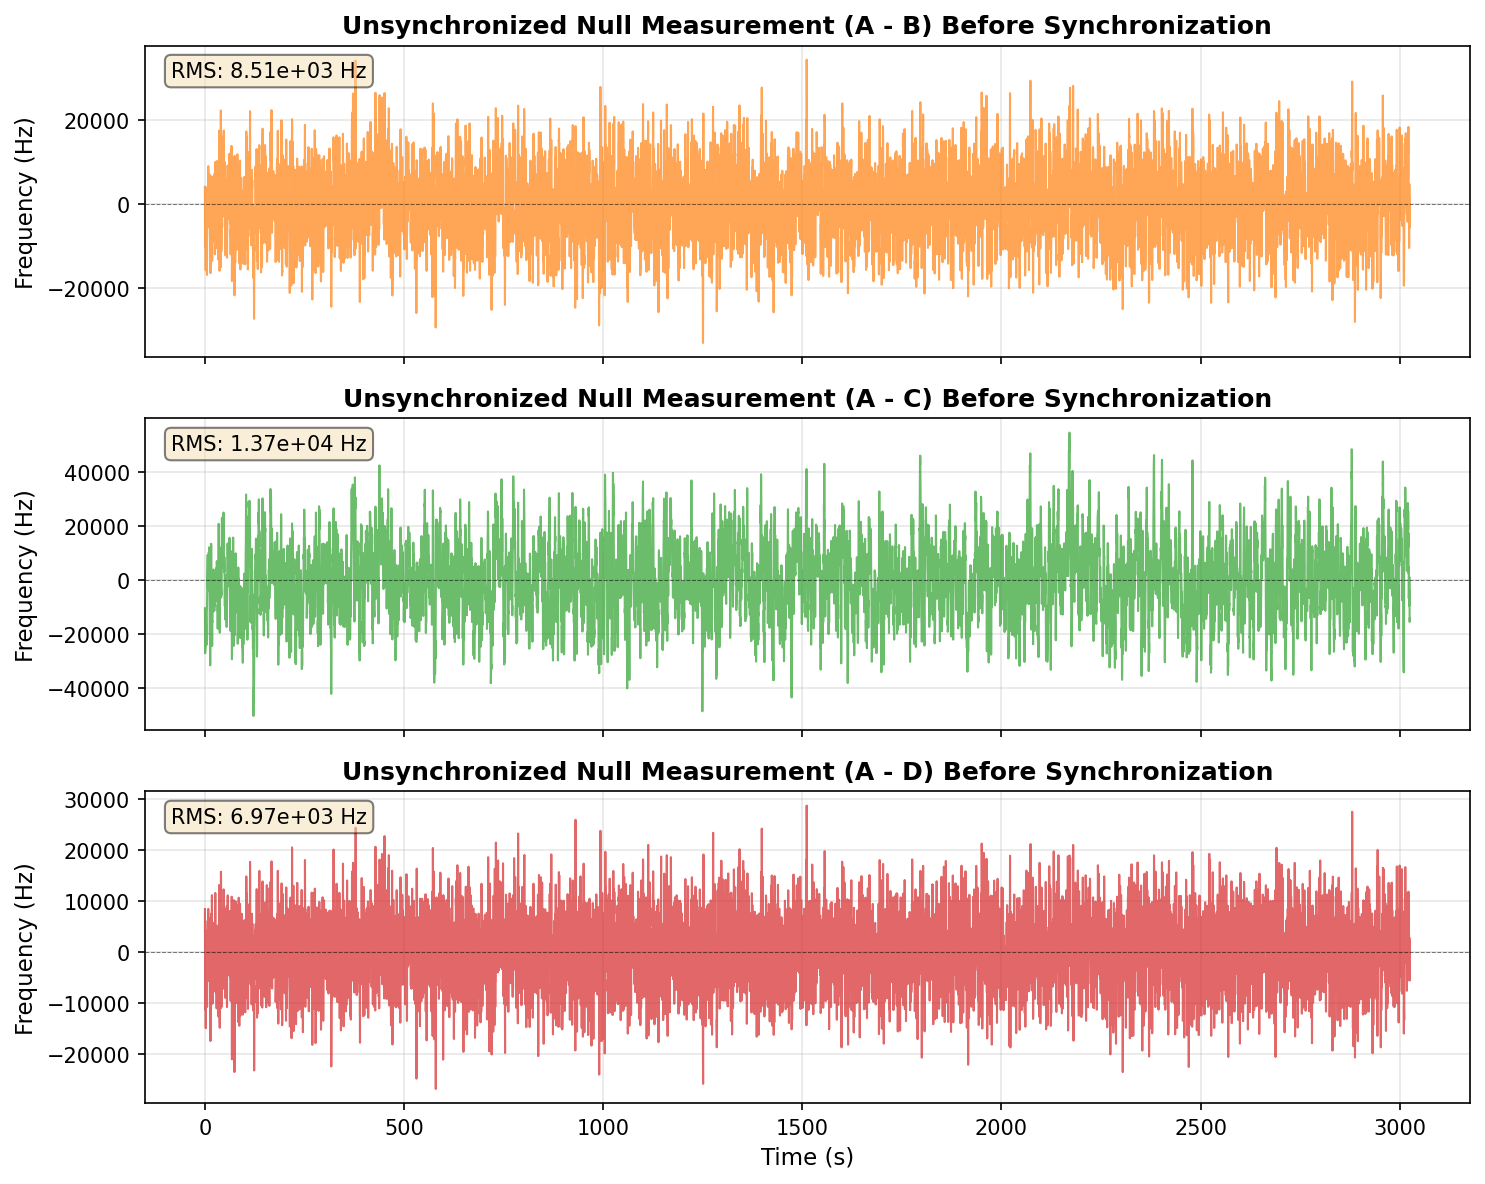

Unsynchronized null measurement RMS:
  A-B: 8.51e+03 Hz
  A-C: 1.37e+04 Hz
  A-D: 6.97e+03 Hz

Note: When synchronized, these should all be close to zero (null measurements)


In [5]:
# Compute unsynchronized differences
unsynced_AB = signal_A_shifted - signal_B_shifted
unsynced_AC = signal_A_shifted - signal_C_shifted
unsynced_AD = signal_A_shifted - signal_D_shifted

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

time_axis_shifted = np.arange(len(unsynced_AB)) / fs
colors = ['#ff7f0e', '#2ca02c', '#d62728']
labels = ['A - B', 'A - C', 'A - D']
differences = [unsynced_AB, unsynced_AC, unsynced_AD]

for i, (diff, color, label) in enumerate(zip(differences, colors, labels)):
    axes[i].plot(time_axis_shifted, diff, color=color, linewidth=1, alpha=0.7)
    axes[i].axhline(y=0, color='black', linestyle='--', linewidth=0.5, alpha=0.5)
    axes[i].set_ylabel('Frequency (Hz)', fontsize=11)
    axes[i].set_title(f'Unsynchronized Null Measurement ({label}) Before Synchronization', 
                     fontsize=12, fontweight='bold')
    axes[i].grid(True, alpha=0.3)
    axes[i].text(0.02, 0.95, f'RMS: {np.std(diff):.2e} Hz', 
                 transform=axes[i].transAxes, verticalalignment='top',
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

axes[-1].set_xlabel('Time (s)', fontsize=11)

fig.tight_layout()
plt.show()

print(f"Unsynchronized null measurement RMS:")
print(f"  A-B: {np.std(unsynced_AB):.2e} Hz")
print(f"  A-C: {np.std(unsynced_AC):.2e} Hz")
print(f"  A-D: {np.std(unsynced_AD):.2e} Hz")
print(f"\nNote: When synchronized, these should all be close to zero (null measurements)")

## Synchronize the Signals

Now we'll use the `sync_multiple_twosignals` function to automatically detect and correct the time offsets for all pairs. The optimization finds the offsets that minimize the null measurement residual for each pair, recovering the nulls (A-B ≈ 0, A-C ≈ 0, A-D ≈ 0).

In [6]:
# Prepare input signals (A is the reference, B, C, D are secondary signals)
in_signals = [signal_A_shifted, signal_B_shifted, signal_C_shifted, signal_D_shifted]

# Initial offset guesses (optional, can be None for automatic detection)
# One guess per pair: [A,B], [A,C], [A,D]
init_offsets = [None, None, None]  # Will default to [0.0] for each pair

# Call sync_multiple_twosignals
print("Starting multiple 2-signal synchronization...")
print("=" * 60)
print(f"Reference signal: A (signal 0)")
print(f"Secondary signals: B (signal 1), C (signal 2), D (signal 3)")
print(f"Pairs to synchronize: [A,B], [A,C], [A,D]")
print("=" * 60)

results = sync_multiple_twosignals(
    in_signals=in_signals,
    fs=fs,
    p_lpsd=p_lpsd,
    init_offsets=init_offsets,
    model="fluc",  # Use fluctuation frequency model
    domain="freq",  # Optimize in frequency domain
    method="Nelder-Mead",  # Optimization method
    interp_order=121,  # High-order interpolation for accuracy
    n_truncate=None,  # Auto-calculate truncation
    clock_refs=None,  # No clock jitter correction
)

print("=" * 60)
print("\nSynchronization complete!")
print(f"\nNumber of synchronized pairs: {len(results)}")
print(f"\nOptimized time offsets:")
print(f"  Pair [A,B]: {results[0][1].timer_offsets[0]:.6f} seconds (true: {true_offset_B:.6f} s)")
print(f"  Pair [A,C]: {results[1][1].timer_offsets[0]:.6f} seconds (true: {true_offset_C:.6f} s)")
print(f"  Pair [A,D]: {results[2][1].timer_offsets[0]:.6f} seconds (true: {true_offset_D:.6f} s)")
print(f"\nOffset errors:")
print(f"  Pair [A,B]: {abs(results[0][1].timer_offsets[0] - true_offset_B):.6f} seconds")
print(f"  Pair [A,C]: {abs(results[1][1].timer_offsets[0] - true_offset_C):.6f} seconds")
print(f"  Pair [A,D]: {abs(results[2][1].timer_offsets[0] - true_offset_D):.6f} seconds")
print(f"\nTDIR precision:")
print(f"  Pair [A,B]: {results[0][1].TDIR_precision:.2e} seconds")
print(f"  Pair [A,C]: {results[1][1].TDIR_precision:.2e} seconds")
print(f"  Pair [A,D]: {results[2][1].TDIR_precision:.2e} seconds")

Starting multiple 2-signal synchronization...
Reference signal: A (signal 0)
Secondary signals: B (signal 1), C (signal 2), D (signal 3)
Pairs to synchronize: [A,B], [A,C], [A,D]
# ===== Synchronization Result [2-signal-sync] ==========
    TDIR result (sec) = [0.]
    TDIR success = True
    TDIR message = Optimization terminated successfully.
# ===== Synchronization Result [2-signal-sync] ==========
    TDIR result (sec) = [0.]
    TDIR success = True
    TDIR message = Optimization terminated successfully.
# ===== Synchronization Result [2-signal-sync] ==========
    TDIR result (sec) = [0.]
    TDIR success = True
    TDIR message = Optimization terminated successfully.

Synchronization complete!

Number of synchronized pairs: 3

Optimized time offsets:
  Pair [A,B]: 0.000000 seconds (true: 0.909091 s)
  Pair [A,C]: 0.000000 seconds (true: 2.424242 s)
  Pair [A,D]: 0.000000 seconds (true: 0.606061 s)

Offset errors:
  Pair [A,B]: 0.909091 seconds
  Pair [A,C]: 2.424242 seconds
  Pa

## Plot 3: Synchronized vs Unsynchronized Null Measurements (Time Domain)

Compare the synchronized and unsynchronized null measurements in the time domain for each pair. After synchronization, the null measurements should be close to zero.

/Users/mdovale/Work-local/synctools/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:222: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/mdovale/Work-local/synctools/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:180: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/Users/mdovale/Work-local/synctools/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:214: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


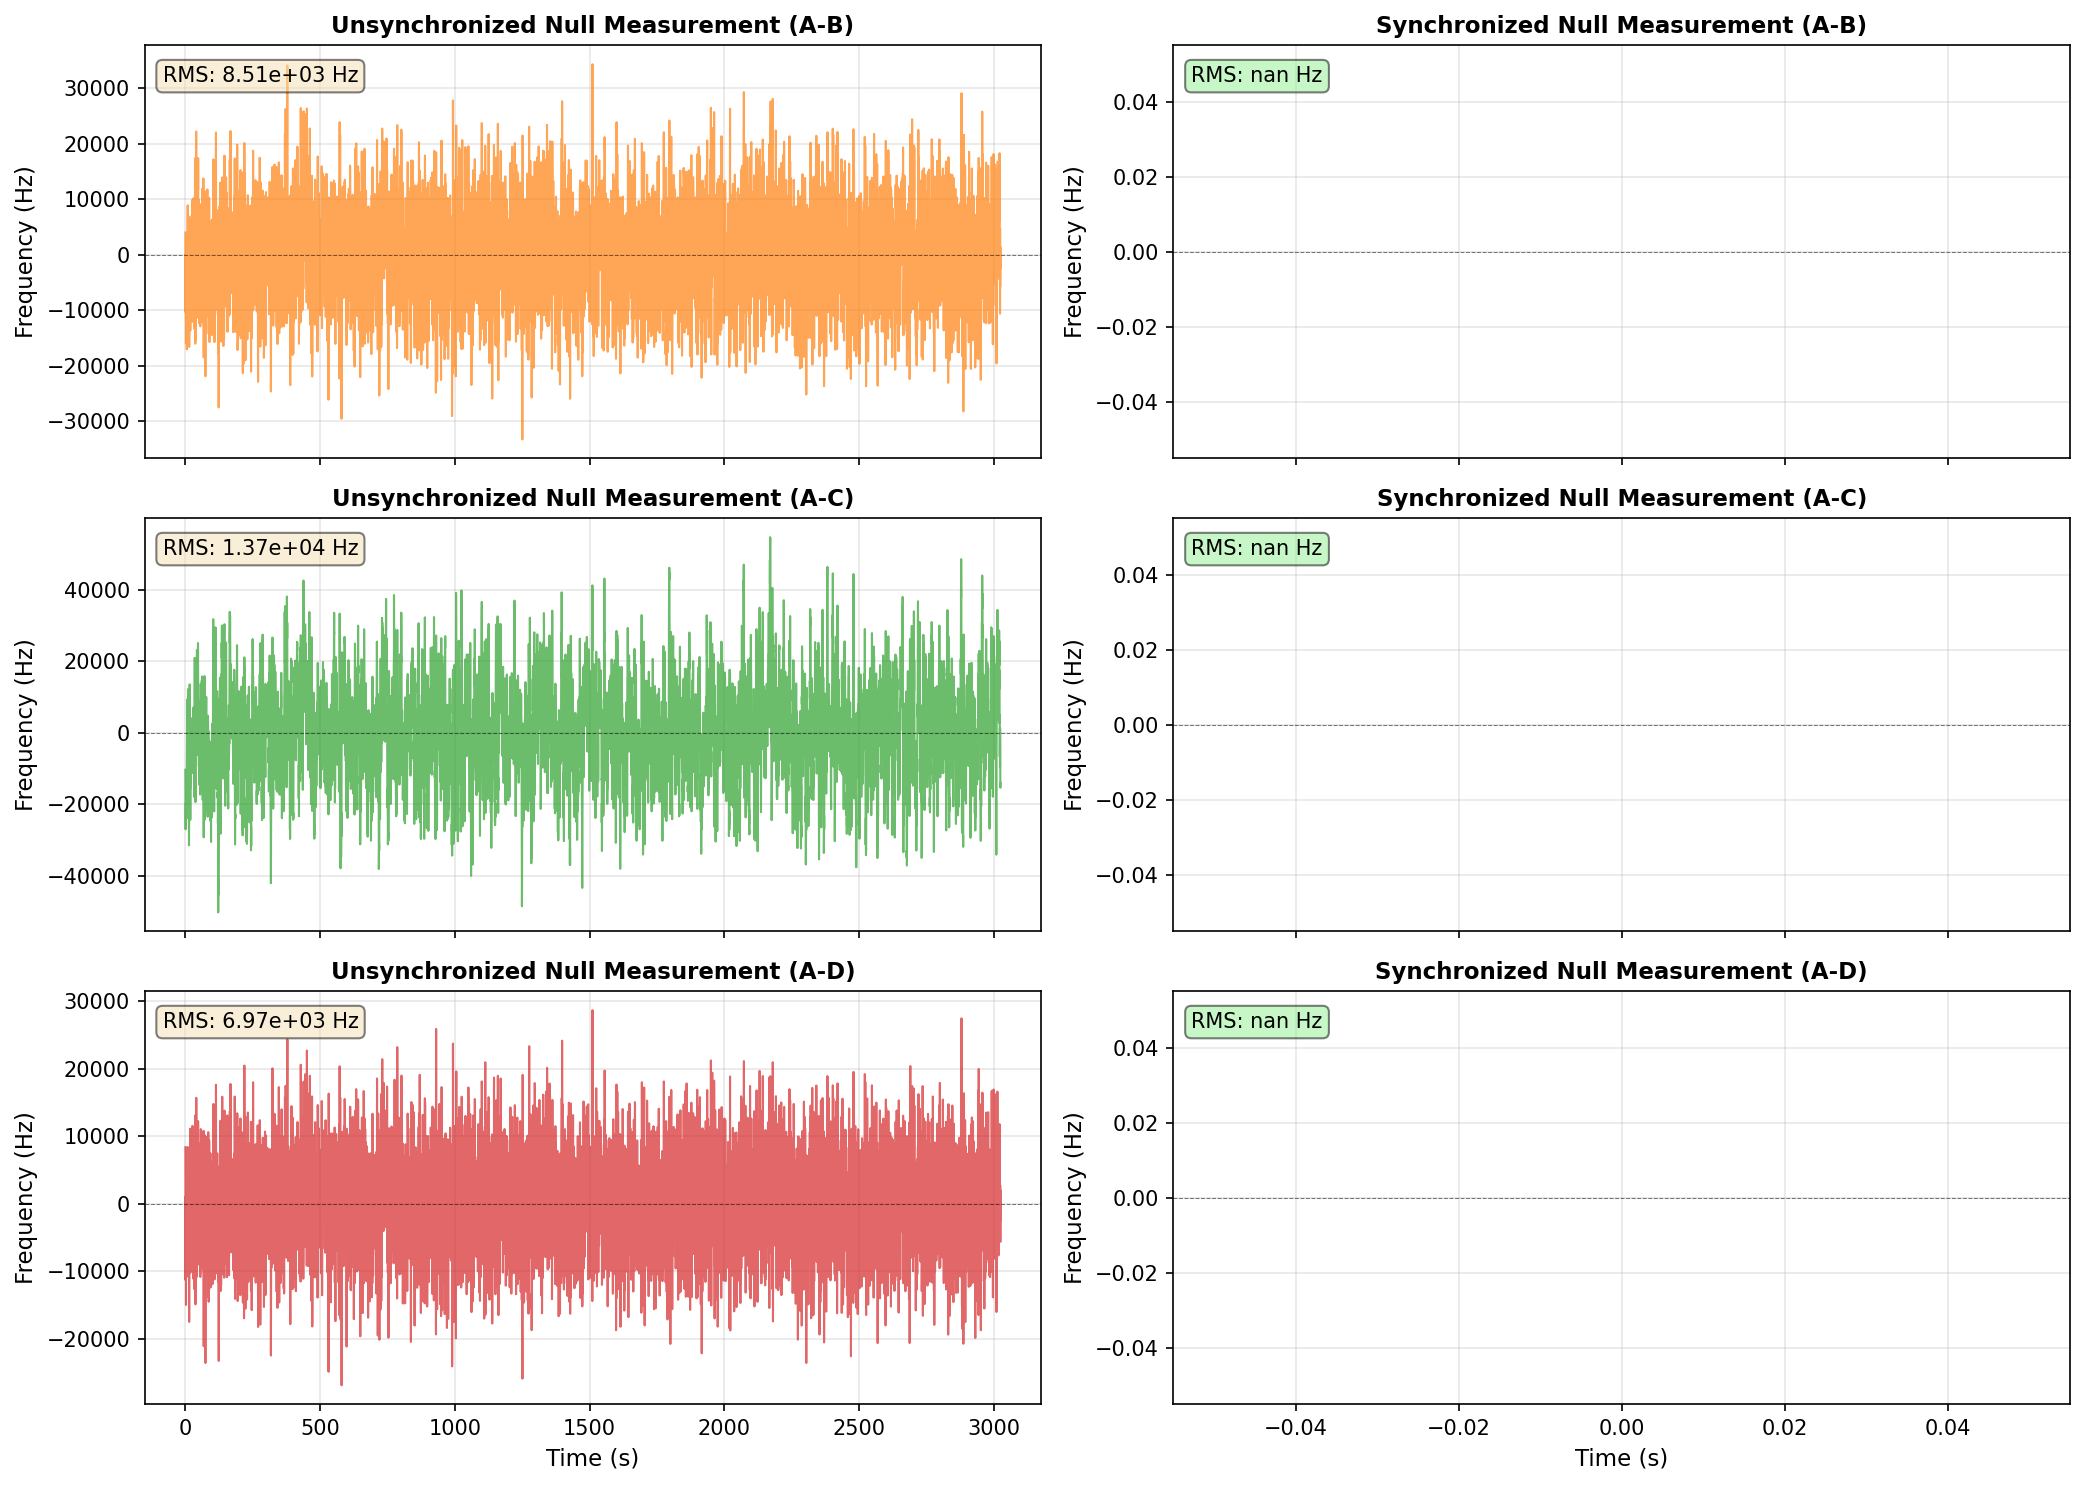

Improvement factors:
  A-B: nanx reduction in RMS
  A-C: nanx reduction in RMS
  A-D: nanx reduction in RMS


In [7]:
fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex='col')

pairs = ['A-B', 'A-C', 'A-D']
colors = ['#ff7f0e', '#2ca02c', '#d62728']

for i, (pair_name, color, (unsynced_obj, synced_obj)) in enumerate(zip(pairs, colors, results)):
    # Unsynchronized difference
    time_unsynced = unsynced_obj.tau
    axes[i, 0].plot(time_unsynced, unsynced_obj.main.freq, color=color, linewidth=1, alpha=0.7)
    axes[i, 0].axhline(y=0, color='black', linestyle='--', linewidth=0.5, alpha=0.5)
    axes[i, 0].set_ylabel('Frequency (Hz)', fontsize=11)
    axes[i, 0].set_title(f'Unsynchronized Null Measurement ({pair_name})', fontsize=11, fontweight='bold')
    axes[i, 0].grid(True, alpha=0.3)
    axes[i, 0].text(0.02, 0.95, f'RMS: {np.std(unsynced_obj.main.freq):.2e} Hz', 
                    transform=axes[i, 0].transAxes, verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # Synchronized difference
    time_synced = synced_obj.tau
    axes[i, 1].plot(time_synced, synced_obj.freq['time'], color=color, linewidth=1.5)
    axes[i, 1].axhline(y=0, color='black', linestyle='--', linewidth=0.5, alpha=0.5, label='Null (zero)')
    axes[i, 1].set_ylabel('Frequency (Hz)', fontsize=11)
    axes[i, 1].set_title(f'Synchronized Null Measurement ({pair_name})', fontsize=11, fontweight='bold')
    axes[i, 1].grid(True, alpha=0.3)
    axes[i, 1].text(0.02, 0.95, f'RMS: {np.std(synced_obj.freq["time"]):.2e} Hz', 
                    transform=axes[i, 1].transAxes, verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))

axes[-1, 0].set_xlabel('Time (s)', fontsize=11)
axes[-1, 1].set_xlabel('Time (s)', fontsize=11)

fig.tight_layout()
plt.show()

print(f"Improvement factors:")
for i, (pair_name, (unsynced_obj, synced_obj)) in enumerate(zip(pairs, results)):
    improvement = np.std(unsynced_obj.main.freq) / np.std(synced_obj.freq['time'])
    print(f"  {pair_name}: {improvement:.2f}x reduction in RMS")

## Plot 4: Frequency Amplitude Spectral Density (ASD) Comparison

Compare the frequency noise spectra before and after synchronization for all pairs.

IndexError: index 1 is out of bounds for axis 0 with size 0

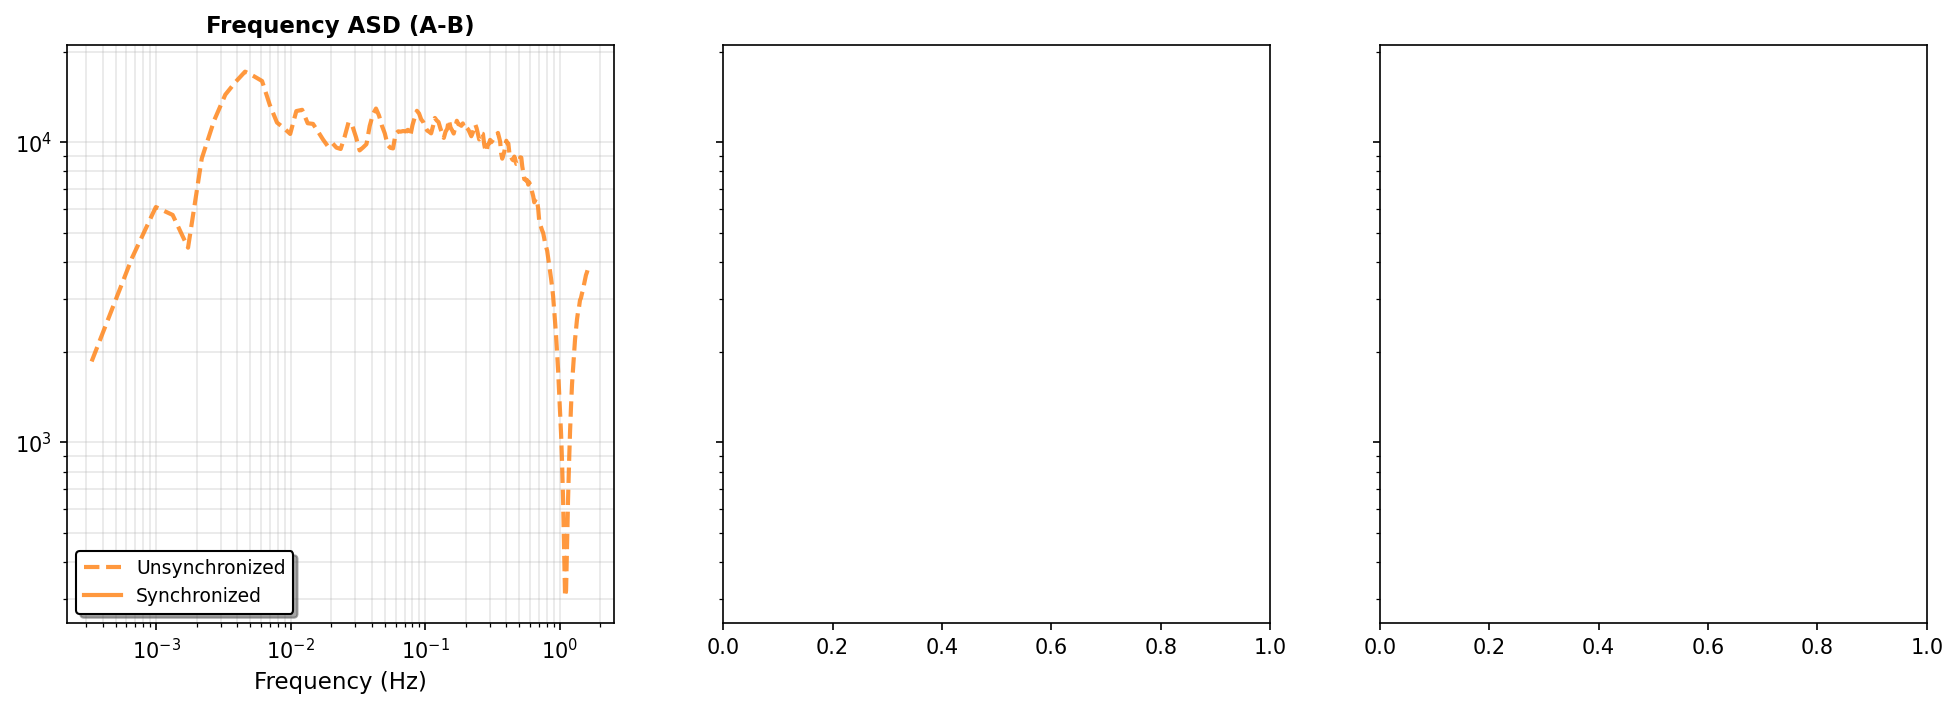

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

pairs = ['A-B', 'A-C', 'A-D']
colors = ['#ff7f0e', '#2ca02c', '#d62728']

for i, (ax, pair_name, color, (unsynced_obj, synced_obj)) in enumerate(zip(axes, pairs, colors, results)):
    # Plot frequency ASDs
    ax.loglog(unsynced_obj.main.fourier_freq, unsynced_obj.main.freq_asd, 
              color=color, linewidth=2, label='Unsynchronized', alpha=0.8, linestyle='--')
    ax.loglog(synced_obj.fourier_freq, synced_obj.freq['asd'], 
              color=color, linewidth=2, label='Synchronized', alpha=0.8)
    
    ax.set_xlabel('Frequency (Hz)', fontsize=11)
    ax.set_title(f'Frequency ASD ({pair_name})', fontsize=11, fontweight='bold')
    ax.legend(loc='best', edgecolor='black', fancybox=True, shadow=True, framealpha=1, fontsize=9)
    ax.grid(True, alpha=0.3, which='both')
    ax.set_xlim([min(unsynced_obj.main.fourier_freq[1], synced_obj.fourier_freq[1]), 
                 max(unsynced_obj.main.fourier_freq[-1], synced_obj.fourier_freq[-1])])

axes[0].set_ylabel('Frequency ASD (Hz/√Hz)', fontsize=11)

fig.tight_layout()
plt.show()

## Plot 5: Phase Amplitude Spectral Density (ASD) Comparison

Compare the phase noise spectra before and after synchronization for all pairs. This is particularly important for precision measurements.

IndexError: index 1 is out of bounds for axis 0 with size 0

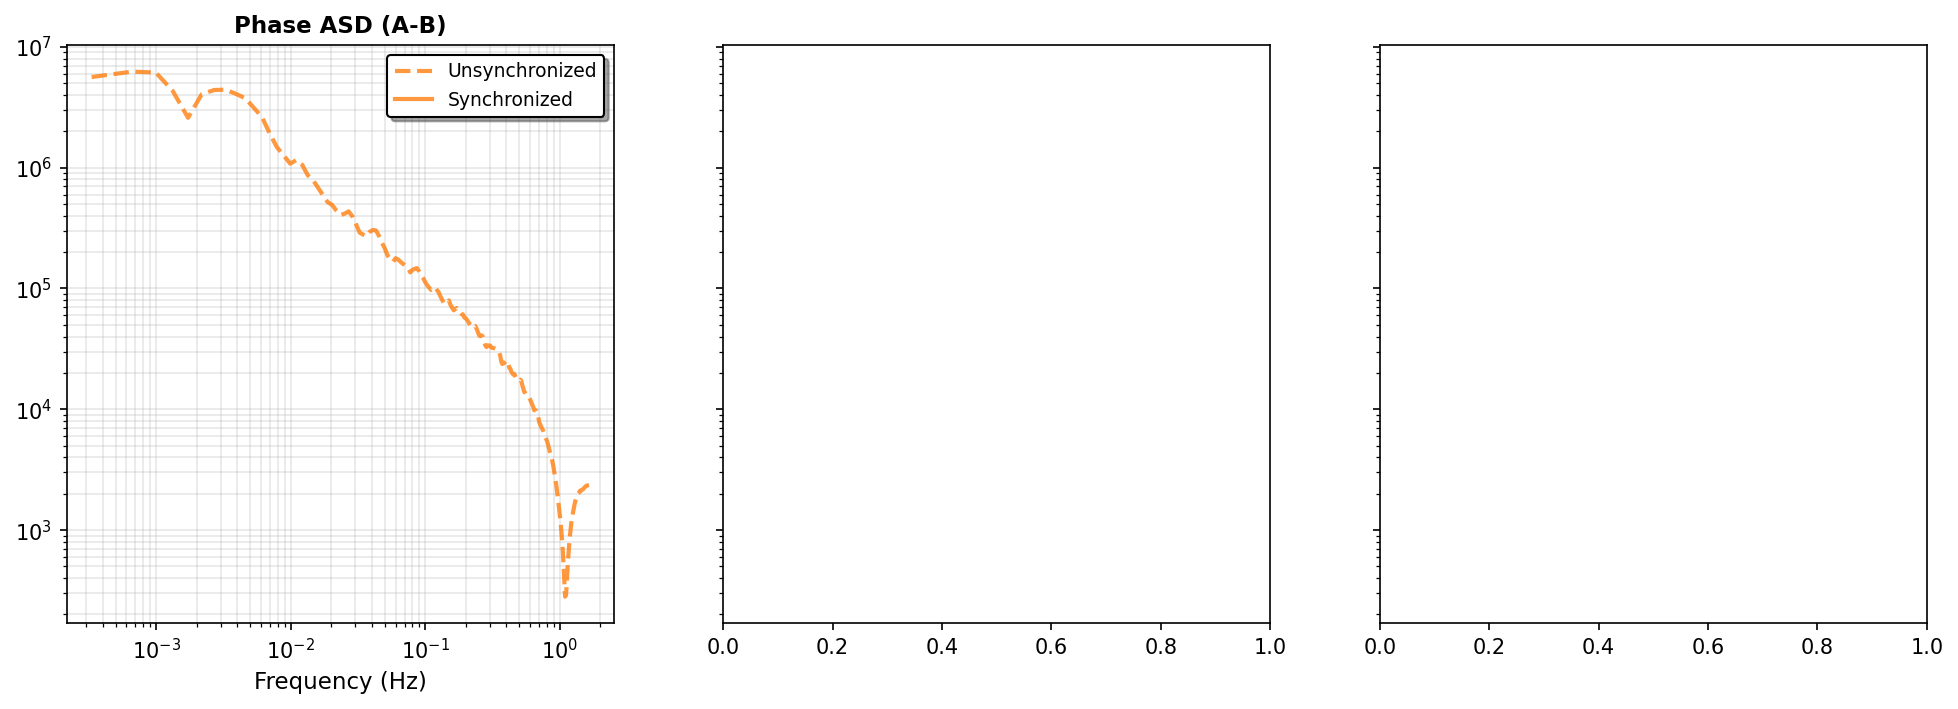

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

pairs = ['A-B', 'A-C', 'A-D']
colors = ['#ff7f0e', '#2ca02c', '#d62728']

for i, (ax, pair_name, color, (unsynced_obj, synced_obj)) in enumerate(zip(axes, pairs, colors, results)):
    # Plot phase ASDs
    ax.loglog(unsynced_obj.main.fourier_freq, unsynced_obj.main.phase_asd, 
              color=color, linewidth=2, label='Unsynchronized', alpha=0.8, linestyle='--')
    ax.loglog(synced_obj.fourier_freq, synced_obj.phase['asd'], 
              color=color, linewidth=2, label='Synchronized', alpha=0.8)
    
    # Add TDIR residual if available
    if len(synced_obj.TDIR_residual_asd) > 0:
        ax.loglog(synced_obj.fourier_freq, synced_obj.TDIR_residual_asd, 
                  color='#9467bd', linewidth=1.5, linestyle=':', 
                  label='TDIR Residual', alpha=0.7)
    
    ax.set_xlabel('Frequency (Hz)', fontsize=11)
    ax.set_title(f'Phase ASD ({pair_name})', fontsize=11, fontweight='bold')
    ax.legend(loc='best', edgecolor='black', fancybox=True, shadow=True, framealpha=1, fontsize=9)
    ax.grid(True, alpha=0.3, which='both')
    ax.set_xlim([min(unsynced_obj.main.fourier_freq[1], synced_obj.fourier_freq[1]), 
                 max(unsynced_obj.main.fourier_freq[-1], synced_obj.fourier_freq[-1])])

axes[0].set_ylabel('Phase ASD (rad/√Hz)', fontsize=11)

fig.tight_layout()
plt.show()

## Plot 6: Phase Time Series Comparison

Visualize the phase evolution in the time domain before and after synchronization for all pairs.

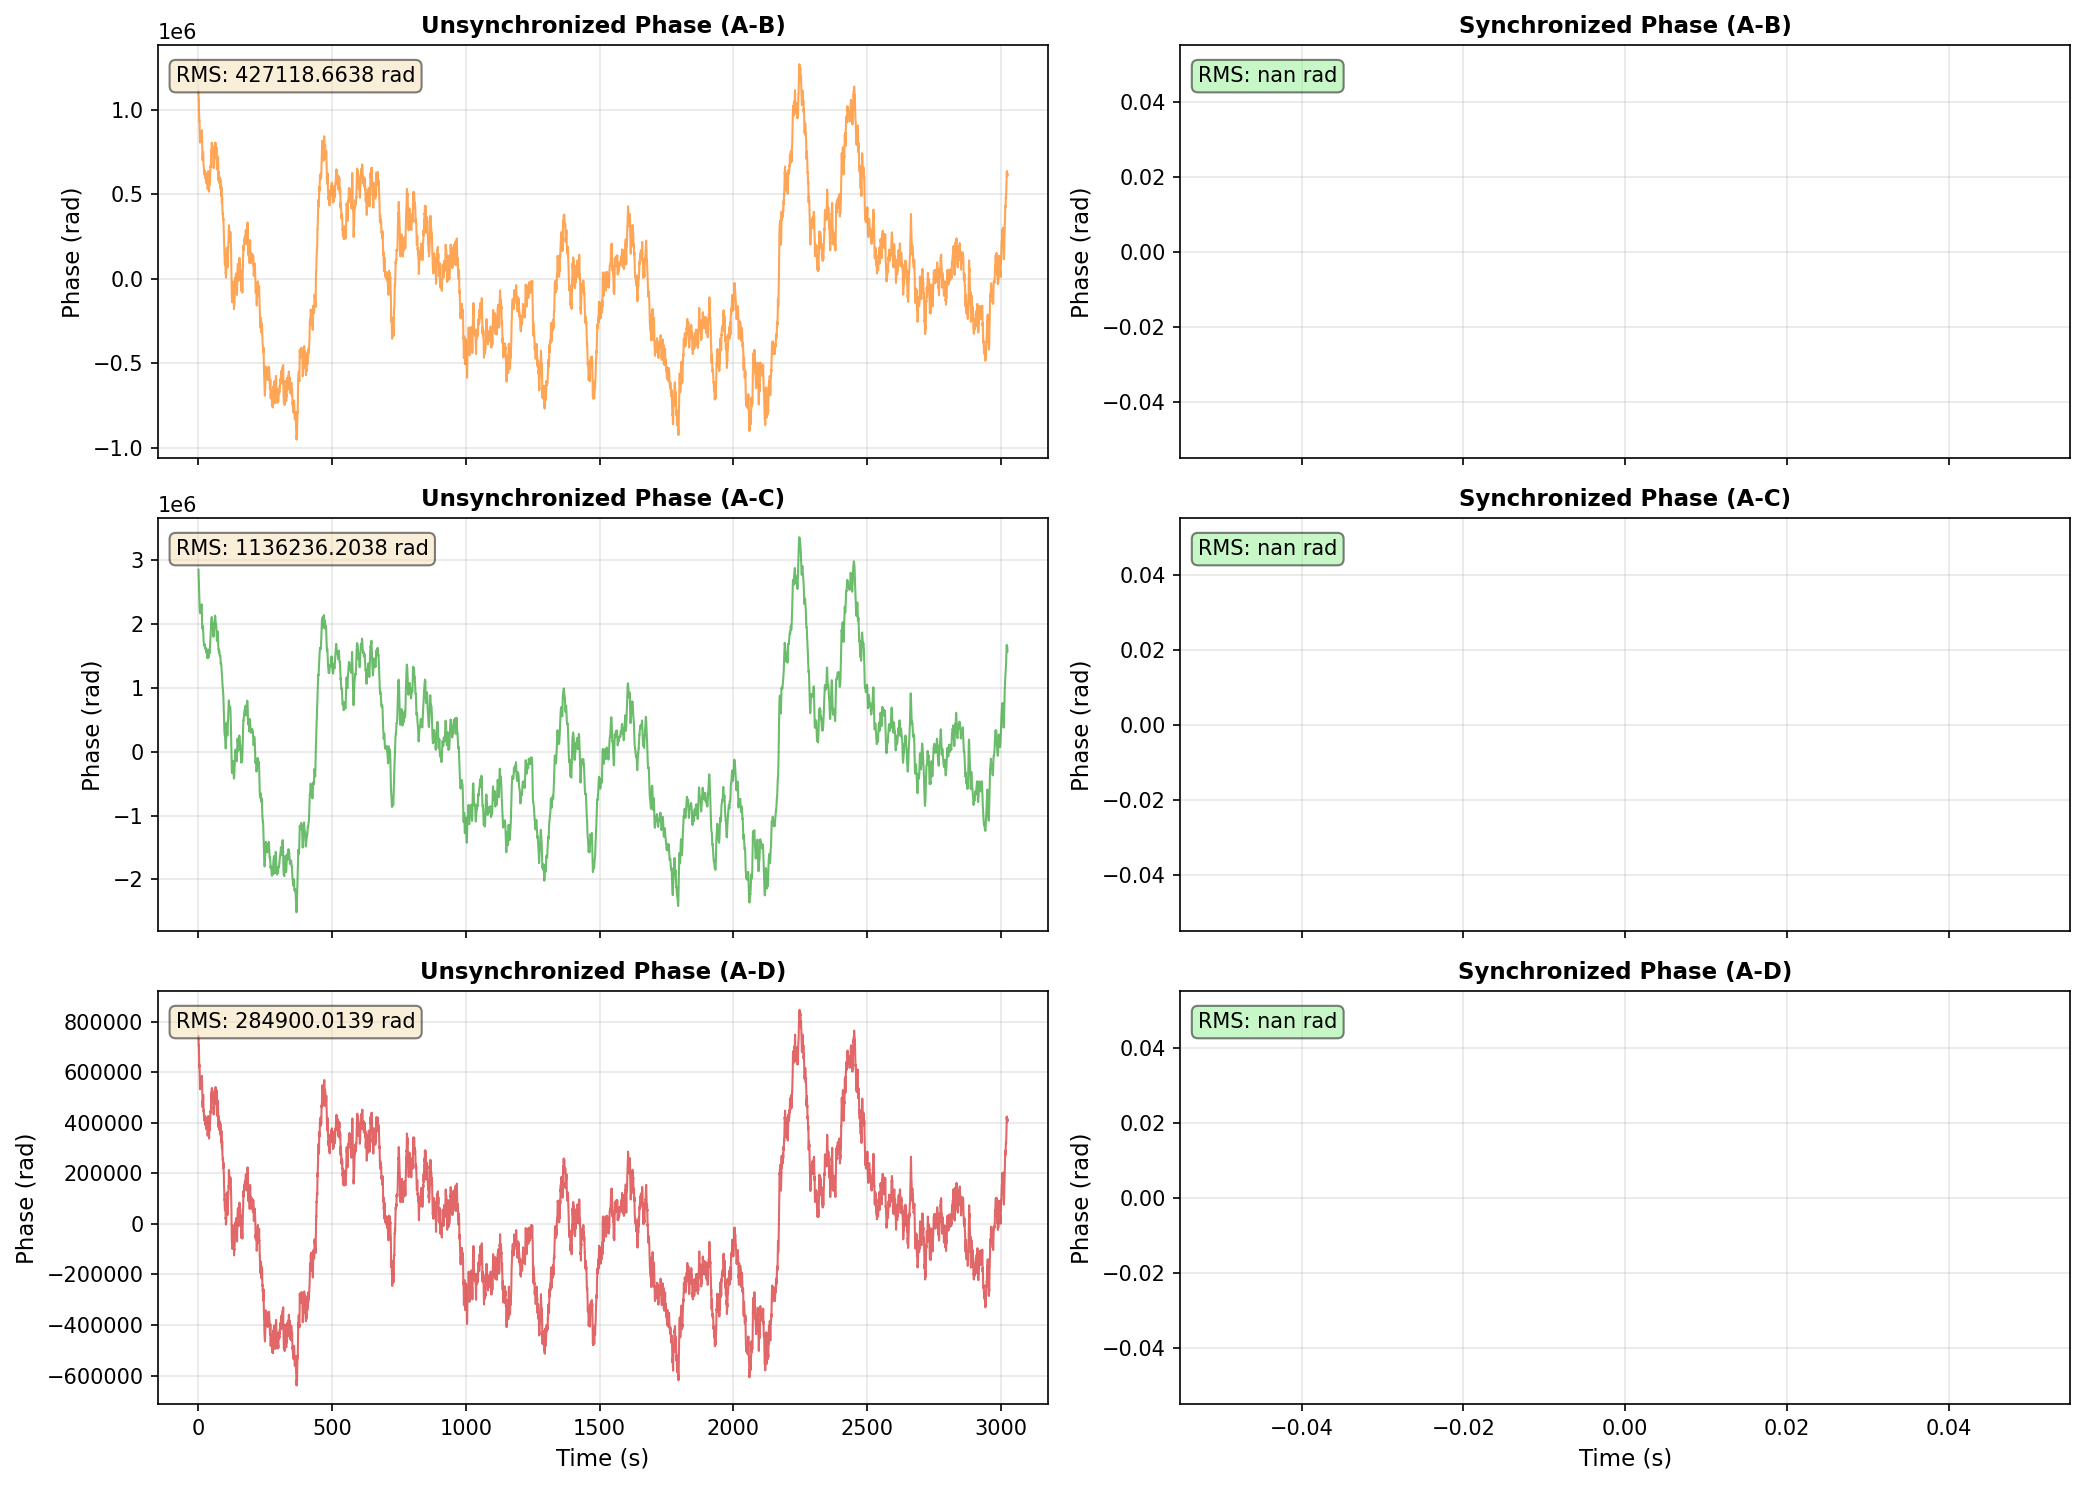

In [10]:
fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex='col')

pairs = ['A-B', 'A-C', 'A-D']
colors = ['#ff7f0e', '#2ca02c', '#d62728']

for i, (pair_name, color, (unsynced_obj, synced_obj)) in enumerate(zip(pairs, colors, results)):
    # Unsynchronized phase
    axes[i, 0].plot(unsynced_obj.tau, unsynced_obj.main.phase, color=color, linewidth=1, alpha=0.7)
    axes[i, 0].set_ylabel('Phase (rad)', fontsize=11)
    axes[i, 0].set_title(f'Unsynchronized Phase ({pair_name})', fontsize=11, fontweight='bold')
    axes[i, 0].grid(True, alpha=0.3)
    axes[i, 0].text(0.02, 0.95, f'RMS: {np.std(unsynced_obj.main.phase):.4f} rad', 
                    transform=axes[i, 0].transAxes, verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # Synchronized phase
    axes[i, 1].plot(synced_obj.tau, synced_obj.phase['time'], color=color, linewidth=1.5)
    axes[i, 1].set_ylabel('Phase (rad)', fontsize=11)
    axes[i, 1].set_title(f'Synchronized Phase ({pair_name})', fontsize=11, fontweight='bold')
    axes[i, 1].grid(True, alpha=0.3)
    axes[i, 1].text(0.02, 0.95, f'RMS: {np.std(synced_obj.phase['time']):.4f} rad', 
                    transform=axes[i, 1].transAxes, verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))

axes[-1, 0].set_xlabel('Time (s)', fontsize=11)
axes[-1, 1].set_xlabel('Time (s)', fontsize=11)

fig.tight_layout()
plt.show()

## Plot 7: Summary - All Optimized Time Offsets

Visualize all the optimized time offsets in a summary plot.

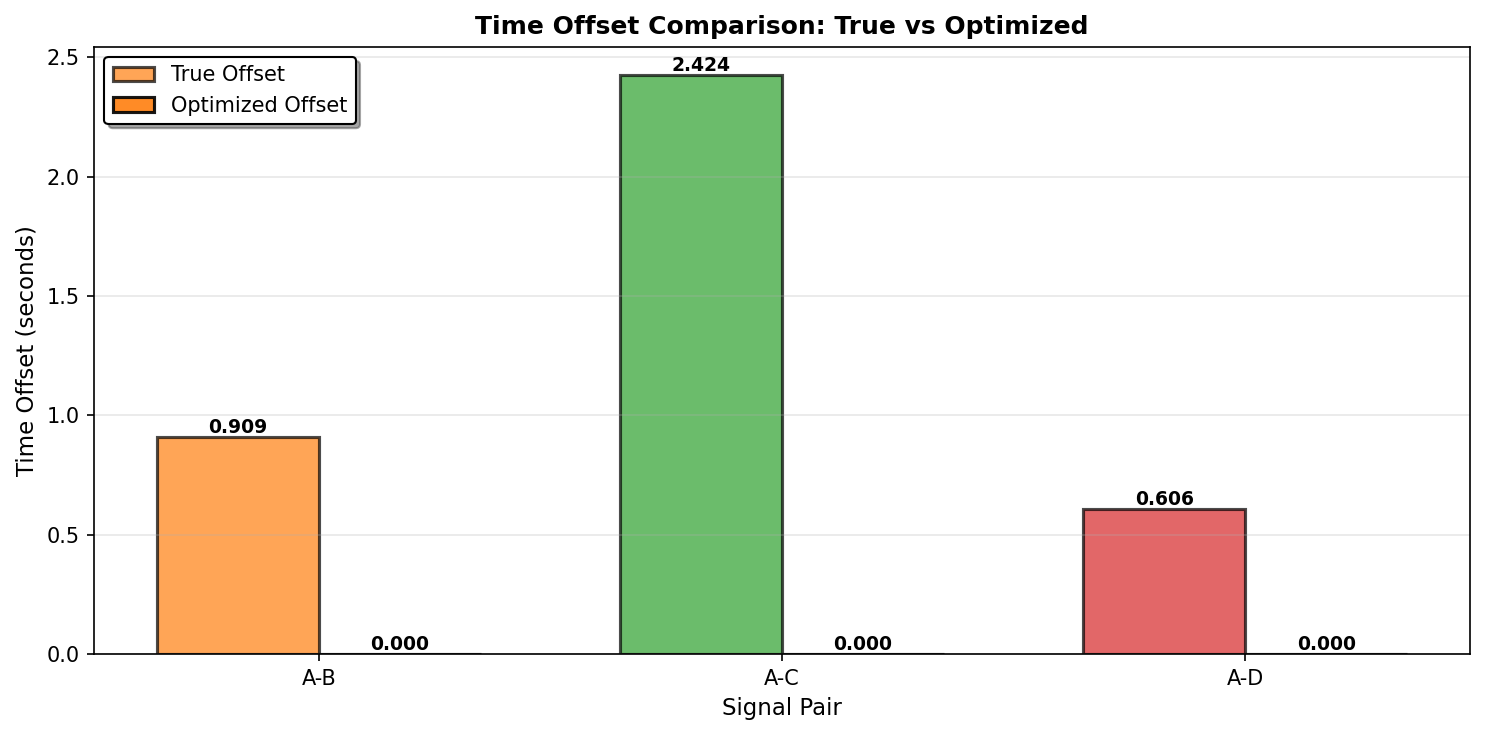


Summary of synchronization results:
Pair     True Offset (s)    Optimized (s)      Error (s)       TDIR Precision    
--------------------------------------------------------------------------------
A-B      0.909091           0.000000           0.909091        nan               
A-C      2.424242           0.000000           2.424242        nan               
A-D      0.606061           0.000000           0.606061        nan               


In [11]:
fig, ax = plt.subplots(figsize=(10, 5))

pairs = ['A-B', 'A-C', 'A-D']
colors = ['#ff7f0e', '#2ca02c', '#d62728']
true_offsets = [true_offset_B, true_offset_C, true_offset_D]
optimized_offsets = [results[i][1].timer_offsets[0] for i in range(len(results))]

x_pos = np.arange(len(pairs))
width = 0.35

bars1 = ax.bar(x_pos - width/2, true_offsets, width, label='True Offset', 
               color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
bars2 = ax.bar(x_pos + width/2, optimized_offsets, width, label='Optimized Offset', 
               color=colors, alpha=0.9, edgecolor='black', linewidth=1.5)

ax.set_xlabel('Signal Pair', fontsize=11)
ax.set_ylabel('Time Offset (seconds)', fontsize=11)
ax.set_title('Time Offset Comparison: True vs Optimized', fontsize=12, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(pairs)
ax.legend(loc='upper left', edgecolor='black', fancybox=True, shadow=True, framealpha=1)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, (true, opt) in enumerate(zip(true_offsets, optimized_offsets)):
    ax.text(i - width/2, true, f'{true:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.text(i + width/2, opt, f'{opt:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

fig.tight_layout()
plt.show()

print(f"\nSummary of synchronization results:")
print(f"{'Pair':<8} {'True Offset (s)':<18} {'Optimized (s)':<18} {'Error (s)':<15} {'TDIR Precision':<18}")
print("-" * 80)
for i, pair_name in enumerate(pairs):
    true = true_offsets[i]
    opt = optimized_offsets[i]
    error = abs(opt - true)
    tdir = results[i][1].TDIR_precision
    print(f"{pair_name:<8} {true:<18.6f} {opt:<18.6f} {error:<15.6f} {tdir:<18.2e}")

## Summary

This notebook demonstrated the `sync_multiple_twosignals` function's ability for **multiple 2-signal synchronizations** using a common reference:

1. **Automatically detect time offsets** between multiple phasemeter signals and a reference signal
2. **Synchronize multiple pairs simultaneously** [A,B], [A,C], [A,D], etc., where A is the reference
3. **Correct synchronization errors** through optimization for each pair independently
4. **Recover the null measurements** (A-B ≈ 0, A-C ≈ 0, A-D ≈ 0) by finding the correct time offsets
5. **Significantly reduce noise** in all null measurement residuals
6. **Improve spectral characteristics** in both frequency and phase domains for all pairs

The synchronization process successfully recovered the known time offsets for all pairs and restored the null measurements, as evidenced by the reduction in RMS values (approaching zero) and improved spectral density characteristics.

**Key concept:**
- `sync_multiple_twosignals` is useful when you have **multiple phasemeter signals that all need to be synchronized to a common reference**
- The function performs **independent 2-signal synchronizations** for each pair [A,B], [A,C], [A,D], etc.
- Each pair uses the **same reference signal (A)** but can have **different time offsets**
- Both **2-signal and 3-signal sync use null measurements** that should cancel to zero when properly synchronized
- The function optimizes for time offsets that, when applied to the input signals, recover the null measurement for each pair
- When unsynchronized, time offsets cause the null measurements to fail, showing large artifacts
- After synchronization, the null measurements are recovered (close to zero, with only residual noise)

**Use case:** This function is particularly useful in scenarios where you have multiple phasemeters measuring the same beat frequency, and you need to synchronize all of them to a common reference signal for further analysis or combination.